In [2]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline
import pandas as pd
import math
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
import my_module as md

distance_from_bottom_of_image = 33
err_distance_from_bottom_of_image = 0.001
distance_of_laser_from_screen = 160.7
total_distance_of_stepper = 8.7
images_per_measurement = 2
err_distance_of_laser_from_screen = 0.01

In [3]:
df = pd.read_csv('copper_sulphate.csv')
df = md.an_average(df, "distance from bottom", 2)
y = df['distance from bottom'].iloc[-6] + distance_from_bottom_of_image
err_y = err_distance_from_bottom_of_image
x = distance_of_laser_from_screen
err_x  = err_distance_of_laser_from_screen
theta = math.atan(float(y) / x)
err_theta = math.sqrt(((float((y**2)*(err_x**2))/(x**2) + err_y**2))/(x**2 * math.cos(y/x)**4))


df = df.iloc[:-1]
df['delta_y'] = df['distance from bottom'] - y + distance_from_bottom_of_image
df['err_delta_y'] = (df['err_distance from bottom'] ** 2 + err_y ** 2).apply(lambda x: x ** 0.5)
df['delta_theta'] = -(df.apply(lambda row: (math.atan((y + row['delta_y']) / x) - theta) / 2, axis=1))
df['err_delta_theta'] = (
    (
        (df['err_delta_y'] ** 2) * (x ** 2) + 
        ((err_theta) ** 2) * ((x ** 2) + (df['delta_y'] + y) ** 2)**2 + 
        ((err_x ** 2) * ((df['delta_y'] + y) ** 2))**2 + 
        (err_y ** 2) * (x ** 2)
    ) / 
    ((x ** 2 + (df['delta_y'] + y) ** 2) ** 2)
).apply(lambda x: x ** 0.5)

distance = []
total_distance_per_measurement = float(total_distance_of_stepper)/(df.shape[0]-1)
for i in range(df.shape[0] ):
    distance.append(i*total_distance_per_measurement)
df['distance'] = distance
area_under_curve = integrate.cumulative_trapezoid(df['delta_theta'], x=df['distance'], initial=0)
df['height'] = area_under_curve


delta_theta_reverse = np.flip(df['delta_theta'])
distance_reverse = np.flip(df['distance'])
area_under_curve_reverse = integrate.cumulative_trapezoid(delta_theta_reverse, x=distance_reverse, initial=0)
area_under_curve_again = np.flip(area_under_curve_reverse)

area_under_curve = (area_under_curve + area_under_curve_again)/2
df['height'] = area_under_curve
df['err_height'] = abs(area_under_curve - area_under_curve_again)

c:\Users\aksha\OneDrive\Desktop\MXP project\my_module.py:144: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, pd.DataFrame({quantity_col: [avg_quantity], error_col: [rms_error]})], ignore_index=True)


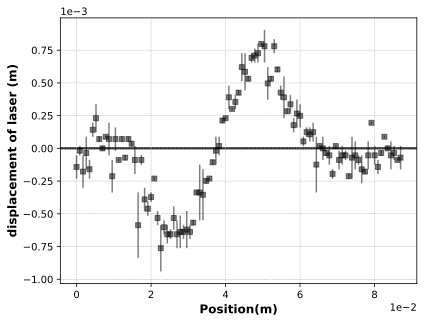

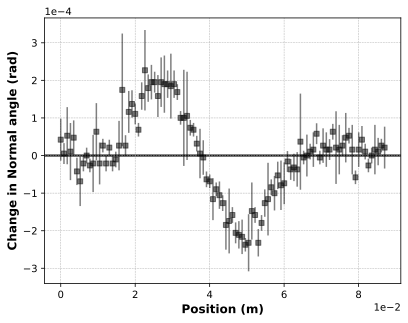

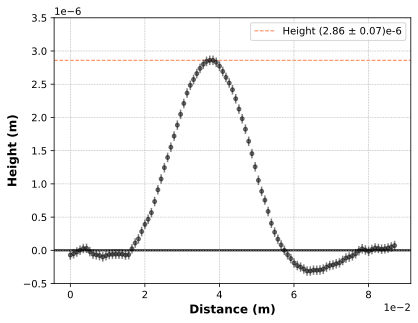

In [6]:
plt.errorbar(df['distance']/100, df['delta_y']/100, yerr=df['err_delta_y']/100, fmt='s', markersize=5, color='black', label='Data', alpha=0.5, zorder=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, zorder=1)
plt.grid(True, linestyle='--', linewidth=0.5)

# Scientific notation for axes
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Set bold fonts for labels
plt.xlabel('Position(m)', fontsize=12, fontweight='bold')
plt.ylabel('displacement of laser (m)', fontsize=12, fontweight='bold')

plt.show()

plt.errorbar(df['distance']/100, df['delta_theta'], yerr=df['err_delta_theta'], fmt='s', markersize=5, color='black', label='Data', alpha=0.5, zorder=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, zorder=1)
plt.grid(True, linestyle='--', linewidth=0.5)

# Scientific notation for axes
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Set bold fonts for labels
plt.xlabel('Position (m)', fontsize=12, fontweight='bold')
plt.ylabel('Change in Normal angle (rad)', fontsize=12, fontweight='bold')

plt.show()


plt.errorbar(df['distance']/100, df['height']/100, yerr=df['err_height']/100, fmt='o', markersize=4, color='black', alpha=0.5, zorder=2)
plt.xlabel('Distance (m)', fontsize=12, fontweight='bold')
plt.ylabel('Height (m)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', linewidth=0.5)

# Add horizontal lines
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, zorder=1)
max_height = df['height'].max()/100
err_max_height = df['err_height'][df['height'].idxmax()]/100
plt.axhline(y=max_height, color='coral', linestyle='--', linewidth=1, label=f'Height (2.86 ± 0.07)e-6', zorder=1)

# Scientific notation for axes
plt.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
plt.legend(fontsize=10, loc='upper right')
plt.ylim(-0.5e-6,3.5e-6)

plt.show()


In [5]:
err_height = err_max_height
height = abs(max_height)
mu_o = 4*math.pi*10**(-7)
B_field =   0.17
err_b_field = 0.02
g  =9.8
rho = 1000
sus = height * 2* g *rho*mu_o/(B_field**2)
err_sus = math.sqrt(
        ((height * -49 / 3125 / (B_field ** 3) * math.pi) * err_b_field) ** 2 +
        ((math.pi * 49 / 6250 / (B_field ** 2)) * err_height) ** 2
    )
exp_sus = 2.71*10**(-6)
per_err = (sus - exp_sus)*100/exp_sus
print("susceptability is ", sus)
print("error in susceptability is", err_sus)
print("height is ",  height)
print("error in height is", err_height)
print("expected susceptability is", exp_sus)
print("error of percentage is", per_err)

susceptability is  2.437243243222871e-06
error in susceptability is 5.767057527111603e-07
height is  2.859767869806992e-06
error in height is 7.159269142427113e-08
expected susceptability is 2.71e-06
error of percentage is -10.064824973325795
